In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import itertools as itt
import tqdm.auto as tqdm
from collections import namedtuple
from scipy.optimize import curve_fit

In [2]:
d = pd.read_csv('../data/raw/DOSERESP.csv')

In [5]:
target = "A549/ATCC"
d = d[d['CELL_NAME'] == target]
d.head()

,RELEASE_DATE,EXPID,PREFIX,NSC,CONCENTRATION_UNIT,LOG_HI_CONCENTRATION,CONCENTRATION,PANEL_NUMBER,CELL_NUMBER,PANEL_NAME,CELL_NAME,PANEL_CODE,COUNT_GIPRCNT,AVERAGE_GIPRCNT,STDDEV_GIPRCNT,COUNT_PTC,AVERAGE_PTC,STDDEV_PTC
38,20210223,0001MD02,S,19893,M,-2.6021,-2.6021,1,4,Non-Small Cell Lung Cancer,A549/ATCC,LNS,1,21.4666,0.0,1,33.5645,0.0
43,20210223,0001MD02,S,19893,M,-2.6021,-3.6021,1,4,Non-Small Cell Lung Cancer,A549/ATCC,LNS,1,28.5948,0.0,1,39.6671,0.0
92,20210223,0001MD03,S,19893,M,-2.6021,-5.6021,1,4,Non-Small Cell Lung Cancer,A549/ATCC,LNS,1,56.5071,0.0,1,62.9205,0.0
113,20210223,0001MD05,S,123127,M,-4.6021,-4.6021,1,4,Non-Small Cell Lung Cancer,A549/ATCC,LNS,1,2.4497,0.0,1,23.3181,0.0
129,20210223,0001MD05,S,123127,M,-4.6021,-6.6021,1,4,Non-Small Cell Lung Cancer,A549/ATCC,LNS,1,43.2634,0.0,1,55.3886,0.0


In [6]:
def sigmoid(x, h, slope):
    return 1 / (1 + np.exp((x - h) / slope))

tbl_keys = ['EXPID', 'CELL_NAME', 'NSC']
IC50 = namedtuple('IC50', tbl_keys + ['IC50'])

ic50_results = []

for (expid, cell_name, nsc), g in tqdm.tqdm(d.groupby(tbl_keys)):
    inh_ptc = g['AVERAGE_PTC']
    conc = g['CONCENTRATION']
    
    if not (inh_ptc.min() < 50 and inh_ptc.max() > 50):
        continue
    
    try:
        conc = g['CONCENTRATION'].values
        inh = g['AVERAGE_PTC'].values / 100
        ps, _ = curve_fit(sigmoid, conc, inh,  p0=[np.median(conc), 1], bounds=([conc.min(), .01], [conc.max(), 100]))
        ic50_results.append(IC50(expid, cell_name, nsc, ps[0]))
    except RuntimeError:
        continue  # Skip if curve fitting fails

ic50_df = pd.DataFrame(ic50_results)

  0%|          | 0/84157 [00:00<?, ?it/s]

/tmp/ipykernel_89464/2237721262.py:19: OptimizeWarning: Covariance of the parameters could not be estimated
  ps, _ = curve_fit(sigmoid, conc, inh,  p0=[np.median(conc), 1], bounds=([conc.min(), .01], [conc.max(), 100]))


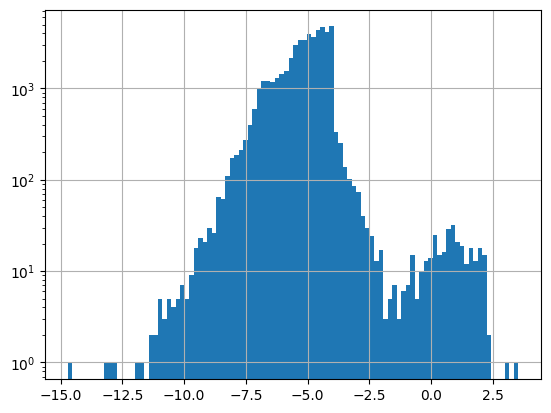

In [7]:
ic50_df['IC50'].hist(bins=100)
plt.yscale('log')

In [8]:
smiles = pd.read_csv("../data/raw/nsc_smiles.csv")
smiles = smiles[
    ~smiles["NSC"].isna() & ~smiles["SMILES"].isna()
]  # remove ill-formed entries: missing SMILES or NSC ident
smiles = smiles.astype({"NSC": int})
smiles

,NSC,SMILES
0,1,CC1=CC(=O)C=CC1=O
1,2,S(Sc1nc2ccccc2s1)c3nc4ccccc4s3
2,3,Oc1c(Cl)cc(cc1[N+](=O)[O-])[N+](=O)[O-]
3,4,Nc1ncc(s1)[N+](=O)[O-]
4,5,Nc1ccc2C(=O)c3ccccc3C(=O)c2c1
...,...,...
325422,855177,COc1nc(C)cc(O[C@@H]2CC[C@H](N)C2)c1c3cc(Nc4cnc...
325423,855286,O.O.NC1=NC(=C(CC(=O)Nc2cnc(C(=O)N[C@@H](CCC(=O...
325424,855361,CCN1C(=NN(C1=O)c2cc3C(=CN(C(=O)c3cc2F)c4ccccc4...
325425,855373,Cc1c(oc2c(F)cc(F)cc12)[C@@H](NC(=O)Nc3cnc(N)nc...


In [9]:
ic50_df = ic50_df.merge(smiles, on='NSC', how='inner')

In [11]:
ic50_df.to_csv('../data/raw/atcc.csv')